In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load the Excel file into a DataFrame
data = pd.read_excel('CBH Data Case 10-24.xlsx')

# Display basic info and first few rows
display(data.info())

# Check for missing values
display(data.isnull().sum())

# Descriptive statistics
display(data.describe())

data.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266340 entries, 0 to 266339
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   SHIFT_ID          266340 non-null  object        
 1   WORKER_ID         266340 non-null  object        
 2   WORKPLACE_ID      266340 non-null  object        
 3   SHIFT_START_AT    266340 non-null  datetime64[ns]
 4   SHIFT_CREATED_AT  266340 non-null  datetime64[ns]
 5   OFFER_VIEWED_AT   266340 non-null  datetime64[ns]
 6   DURATION          266340 non-null  int64         
 7   SLOT              266340 non-null  object        
 8   CLAIMED_AT        13064 non-null   datetime64[ns]
 9   DELETED_AT        55644 non-null   datetime64[ns]
 10  IS_VERIFIED       266340 non-null  bool          
 11  CANCELED_AT       321 non-null     datetime64[ns]
 12  IS_NCNS           266340 non-null  bool          
 13  PAY_RATE          266340 non-null  float64       
 14  CHAR

None

SHIFT_ID                 0
WORKER_ID                0
WORKPLACE_ID             0
SHIFT_START_AT           0
SHIFT_CREATED_AT         0
OFFER_VIEWED_AT          0
DURATION                 0
SLOT                     0
CLAIMED_AT          253276
DELETED_AT          210696
IS_VERIFIED              0
CANCELED_AT         266019
IS_NCNS                  0
PAY_RATE                 0
CHARGE_RATE              0
dtype: int64

,DURATION,PAY_RATE,CHARGE_RATE
count,266340.000000,266340.000000,266340.000000
mean,8.342164,24.164936,31.511906
std,1.155281,4.651970,5.414566
min,0.000000,16.140000,24.000000
25%,8.000000,21.580000,27.000000
50%,8.000000,22.520000,31.000000
75%,9.000000,25.100000,36.000000
max,18.000000,58.570000,64.000000


,SHIFT_ID,WORKER_ID,WORKPLACE_ID,SHIFT_START_AT,SHIFT_CREATED_AT,OFFER_VIEWED_AT,DURATION,SLOT,CLAIMED_AT,DELETED_AT,IS_VERIFIED,CANCELED_AT,IS_NCNS,PAY_RATE,CHARGE_RATE
0,6757580b1e2d97752fd69167,65b01f2e46c0645699081cbe,5e7e45243bfbb200165914ae,2024-12-09 23:00:00,2024-12-09 20:50:19.271,2024-12-09 21:18:42.297,8,pm,NaT,NaT,False,NaT,False,21.29,29
1,675d37d8a1ca6192a74d23f4,65298a18cc967a5cebbd40b6,5e1ce78827ff480016e9133e,2024-12-14 22:30:00,2024-12-14 07:46:32.061,2024-12-14 13:19:30.185,9,pm,NaT,2024-12-14 19:23:43.099,False,NaT,False,23.23,30
2,67550bddd79613f860549322,6696d1c1d0200bf317ee5d3c,626b0b89596c0601c2c39642,2024-12-08 15:00:00,2024-12-08 03:00:45.745,2024-12-08 04:04:14.037,6,am,NaT,NaT,False,NaT,False,21.97,30
3,66f5d05de01fd3697b18c206,66b285d5d0200bf317738e59,5cb9f07135163900163f532c,2024-09-27 14:00:00,2024-09-26 21:21:33.647,2024-09-27 04:19:45.197,8,am,NaT,NaT,False,NaT,False,19.05,28
4,66ee3848e62bb5f43e3baee5,620c6429e2ceb601ad203920,611af67795f4c501662edb31,2024-10-08 21:30:00,2024-09-21 03:06:48.251,2024-10-06 00:46:37.393,8,pm,NaT,NaT,False,NaT,False,22.13,24


In [51]:
# Ensure the SHIFT_START_AT column is in datetime format
data['SHIFT_START_AT'] = pd.to_datetime(data['SHIFT_START_AT'], errors='coerce')

# Extract unique year-month combinations
data['year_month'] = data['SHIFT_START_AT'].dt.to_period('M')
unique_year_months = data['year_month'].dropna().unique()

# Display unique year-month values
print(unique_year_months)


<PeriodArray>
['2024-12', '2024-09', '2024-10', '2024-11', '2025-01']
Length: 5, dtype: period[M]


In [56]:
# Step 1: Convert timestamps to datetime
data['SHIFT_START_AT'] = pd.to_datetime(data['SHIFT_START_AT'])
data['DAY_OF_WEEK'] = data['SHIFT_START_AT'].dt.day_name()  # Extract day name

# Calculate Company Revenue (Charge Rate - Pay Rate)
data['COMPANY_REV'] = data['CHARGE_RATE'] - data['PAY_RATE']

# Step 2: Identify unclaimed shifts (CLAIMED_AT is missing)
unclaimed_shifts = data[data['CLAIMED_AT'].isna()]

# Step 3: Remove duplicates for shifts that have never been claimed (unique SHIFT_IDs)
unclaimed_shifts_unique = unclaimed_shifts.drop_duplicates(subset='SHIFT_ID')

# Step 4: Count unique unclaimed shifts by day of the week and slot
unclaimed_by_day_slot = unclaimed_shifts_unique.groupby(['DAY_OF_WEEK', 'SLOT'])['SHIFT_ID'].count().reset_index()
unclaimed_by_day_slot.columns = ['DAY_OF_WEEK', 'SLOT', 'NUM_UNCLAIMED_SHIFTS']

# Step 5: Calculate total unclaimed hours by summing the DURATION of unique unclaimed shifts
unclaimed_hours_by_day_slot = unclaimed_shifts_unique.groupby(['DAY_OF_WEEK', 'SLOT'])['DURATION'].sum().reset_index()
unclaimed_hours_by_day_slot.columns = ['DAY_OF_WEEK', 'SLOT', 'TOTAL_UNCLAIMED_HOURS']

# Step 6: Compute the average revenue per claimed shift by day and slot
claimed_shifts = data[data['CLAIMED_AT'].notna()]
claimed_by_day_slot = claimed_shifts.groupby(['DAY_OF_WEEK', 'SLOT'])[['COMPANY_REV']].mean().reset_index()
claimed_by_day_slot.columns = ['DAY_OF_WEEK', 'SLOT', 'CLAIMED_AVG_COMPANY_REV']

# Step 7: Merge unclaimed shifts with unclaimed hours and claimed revenue
revenue_by_day_slot = pd.merge(unclaimed_by_day_slot, unclaimed_hours_by_day_slot, on=['DAY_OF_WEEK', 'SLOT'], how='left')
revenue_by_day_slot = pd.merge(revenue_by_day_slot, claimed_by_day_slot, on=['DAY_OF_WEEK', 'SLOT'], how='left')

# Step 8: Fill missing values with 0 (in case there are no unclaimed shifts or revenue for certain slots)
revenue_by_day_slot['TOTAL_UNCLAIMED_HOURS'] = revenue_by_day_slot['TOTAL_UNCLAIMED_HOURS'].fillna(0)
revenue_by_day_slot['NUM_UNCLAIMED_SHIFTS'] = revenue_by_day_slot['NUM_UNCLAIMED_SHIFTS'].fillna(0)

# Step 9: Calculate lost revenue (Total Unclaimed Hours × Claimed Avg Revenue per Shift)
revenue_by_day_slot['LOST_REVENUE'] = revenue_by_day_slot['TOTAL_UNCLAIMED_HOURS'] * revenue_by_day_slot['CLAIMED_AVG_COMPANY_REV']

# Step 10: Compute total lost revenue for slots
total_lost_revenue_slots = revenue_by_day_slot['LOST_REVENUE'].sum()

# Output the results
print(f"\nTotal Estimated Lost Revenue (by Slots): {total_lost_revenue_slots:.2f}")
print("\nRevenue Loss by Day & Slot (Based on Unclaimed Shifts):")
print(revenue_by_day_slot[['DAY_OF_WEEK', 'SLOT', 'NUM_UNCLAIMED_SHIFTS', 'TOTAL_UNCLAIMED_HOURS', 'LOST_REVENUE']].head(25))




Total Estimated Lost Revenue (by Slots): 697745.40

Revenue Loss by Day & Slot (Based on Unclaimed Shifts):
   DAY_OF_WEEK SLOT  NUM_UNCLAIMED_SHIFTS  TOTAL_UNCLAIMED_HOURS  LOST_REVENUE
0       Friday   am                   710                   6092  39876.214916
1       Friday  noc                   387                   3203  20443.796757
2       Friday   pm                   973                   7974  53999.547219
3       Monday   am                   759                   6441  36941.590921
4       Monday  noc                   523                   4360  27655.506212
5       Monday   pm                   785                   6547  41077.760366
6     Saturday   am                   881                   7633  47412.180673
7     Saturday  noc                   544                   4528  33052.107342
8     Saturday   pm                  1216                   9989  68485.380465
9       Sunday   am                  1047                   8972  50801.726336
10      Sunday  noc   

In [47]:


# Convert timestamps to datetime
data['SHIFT_START_AT'] = pd.to_datetime(data['SHIFT_START_AT'])
data['DAY_OF_WEEK'] = data['SHIFT_START_AT'].dt.day_name()  # Extract day name

# Identify claimed and unclaimed shifts
claimed_shifts = data[data['CLAIMED_AT'].notna()]
unclaimed_shifts = data[data['CLAIMED_AT'].isna()]

# ---- Average Pay Rate by Day ----
claimed_by_day = claimed_shifts.groupby('DAY_OF_WEEK')[['PAY_RATE']].mean().reset_index()
unclaimed_by_day = unclaimed_shifts.groupby('DAY_OF_WEEK')[['PAY_RATE']].mean().reset_index()

# Rename columns for clarity
claimed_by_day.columns = ['DAY_OF_WEEK', 'CLAIMED_AVG_PAY_RATE']
unclaimed_by_day.columns = ['DAY_OF_WEEK', 'UNCLAIMED_AVG_PAY_RATE']

# Merge claimed and unclaimed data
pay_rate_by_day = pd.merge(claimed_by_day, unclaimed_by_day, on='DAY_OF_WEEK', how='outer')

# Compute percent difference
pay_rate_by_day['PERCENT_DIFF'] = ((pay_rate_by_day['CLAIMED_AVG_PAY_RATE'] - pay_rate_by_day['UNCLAIMED_AVG_PAY_RATE']) / pay_rate_by_day['UNCLAIMED_AVG_PAY_RATE']) * 100

print("\nAverage Pay Rate by Day with Percent Difference:")
print(pay_rate_by_day)

# ---- Average Pay Rate by Day & Slot ----
claimed_by_day_slot = claimed_shifts.groupby(['DAY_OF_WEEK', 'SLOT'])[['PAY_RATE']].mean().reset_index()
unclaimed_by_day_slot = unclaimed_shifts.groupby(['DAY_OF_WEEK', 'SLOT'])[['PAY_RATE']].mean().reset_index()

# Rename columns
claimed_by_day_slot.columns = ['DAY_OF_WEEK', 'SLOT', 'CLAIMED_AVG_PAY_RATE']
unclaimed_by_day_slot.columns = ['DAY_OF_WEEK', 'SLOT', 'UNCLAIMED_AVG_PAY_RATE']

# Merge claimed and unclaimed data
pay_rate_by_day_slot = pd.merge(claimed_by_day_slot, unclaimed_by_day_slot, on=['DAY_OF_WEEK', 'SLOT'], how='outer')

# Compute percent difference for each slot
pay_rate_by_day_slot['PERCENT_DIFF'] = ((pay_rate_by_day_slot['CLAIMED_AVG_PAY_RATE'] - pay_rate_by_day_slot['UNCLAIMED_AVG_PAY_RATE']) / pay_rate_by_day_slot['UNCLAIMED_AVG_PAY_RATE']) * 100

print("\nAverage Pay Rate by Day & Slot with Percent Difference:")
pay_rate_by_day_slot.head(25)



Average Pay Rate by Day with Percent Difference:
  DAY_OF_WEEK  CLAIMED_AVG_PAY_RATE  UNCLAIMED_AVG_PAY_RATE  PERCENT_DIFF
0      Friday             25.598893               23.467075      9.084295
1      Monday             26.129461               24.130372      8.284536
2    Saturday             25.665698               23.679564      8.387542
3      Sunday             26.694554               24.068955     10.908653
4    Thursday             26.910960               24.243342     11.003507
5     Tuesday             26.844388               24.079224     11.483612
6   Wednesday             28.527047               25.453153     12.076671

Average Pay Rate by Day & Slot with Percent Difference:


,DAY_OF_WEEK,SLOT,CLAIMED_AVG_PAY_RATE,UNCLAIMED_AVG_PAY_RATE,PERCENT_DIFF
0,Friday,am,25.760351,23.524743,9.503219
1,Friday,noc,25.695921,24.118655,6.539611
2,Friday,pm,25.407823,23.233102,9.360443
3,Monday,am,26.404187,24.638873,7.164751
4,Monday,noc,26.023727,24.261133,7.265094
5,Monday,pm,25.955221,23.444959,10.707043
6,Saturday,am,26.387001,24.513246,7.643849
7,Saturday,noc,24.635105,23.160981,6.364689
8,Saturday,pm,25.578029,23.369157,9.452080
9,Sunday,am,27.016627,24.660950,9.552257


In [48]:

# Convert timestamps to datetime
data['SHIFT_START_AT'] = pd.to_datetime(data['SHIFT_START_AT'])
data['DAY_OF_WEEK'] = data['SHIFT_START_AT'].dt.day_name()  # Extract day name

# Calculate Company Revenue (Charge Rate - Pay Rate)
data['COMPANY_REV'] = data['CHARGE_RATE'] - data['PAY_RATE']

# Identify claimed and unclaimed shifts
claimed_shifts = data[data['CLAIMED_AT'].notna()]
unclaimed_shifts = data[data['CLAIMED_AT'].isna()]

# ---- Average Company Revenue by Day ----
claimed_by_day = claimed_shifts.groupby('DAY_OF_WEEK')[['COMPANY_REV']].mean().reset_index()
unclaimed_by_day = unclaimed_shifts.groupby('DAY_OF_WEEK')[['COMPANY_REV']].mean().reset_index()

# Rename columns for clarity
claimed_by_day.columns = ['DAY_OF_WEEK', 'CLAIMED_AVG_COMPANY_REV']
unclaimed_by_day.columns = ['DAY_OF_WEEK', 'UNCLAIMED_AVG_COMPANY_REV']

# Merge claimed and unclaimed data
company_rev_by_day = pd.merge(claimed_by_day, unclaimed_by_day, on='DAY_OF_WEEK', how='outer')

# Compute percent difference
company_rev_by_day['PERCENT_DIFF'] = ((company_rev_by_day['CLAIMED_AVG_COMPANY_REV'] - company_rev_by_day['UNCLAIMED_AVG_COMPANY_REV']) / company_rev_by_day['UNCLAIMED_AVG_COMPANY_REV']) * 100

print("\nAverage Company Revenue by Day with Percent Difference:")
print(company_rev_by_day)

# ---- Average Company Revenue by Day & Slot ----
claimed_by_day_slot = claimed_shifts.groupby(['DAY_OF_WEEK', 'SLOT'])[['COMPANY_REV']].mean().reset_index()
unclaimed_by_day_slot = unclaimed_shifts.groupby(['DAY_OF_WEEK', 'SLOT'])[['COMPANY_REV']].mean().reset_index()

# Rename columns
claimed_by_day_slot.columns = ['DAY_OF_WEEK', 'SLOT', 'CLAIMED_AVG_COMPANY_REV']
unclaimed_by_day_slot.columns = ['DAY_OF_WEEK', 'SLOT', 'UNCLAIMED_AVG_COMPANY_REV']

# Merge claimed and unclaimed data
company_rev_by_day_slot = pd.merge(claimed_by_day_slot, unclaimed_by_day_slot, on=['DAY_OF_WEEK', 'SLOT'], how='outer')

# Compute percent difference for each slot
company_rev_by_day_slot['PERCENT_DIFF'] = ((company_rev_by_day_slot['CLAIMED_AVG_COMPANY_REV'] - company_rev_by_day_slot['UNCLAIMED_AVG_COMPANY_REV']) / company_rev_by_day_slot['UNCLAIMED_AVG_COMPANY_REV']) * 100

print("\nAverage Company Revenue by Day & Slot with Percent Difference:")
company_rev_by_day_slot.head(25)



Average Company Revenue by Day with Percent Difference:
  DAY_OF_WEEK  CLAIMED_AVG_COMPANY_REV  UNCLAIMED_AVG_COMPANY_REV  \
0      Friday                 6.600874                   7.724477   
1      Monday                 6.103050                   7.438383   
2    Saturday                 6.718775                   8.050944   
3      Sunday                 5.883333                   7.113309   
4    Thursday                 5.424319                   7.302686   
5     Tuesday                 5.416111                   7.549236   
6   Wednesday                 3.841774                   5.991554   

   PERCENT_DIFF  
0    -14.546009  
1    -17.951924  
2    -16.546739  
3    -17.291189  
4    -25.721588  
5    -28.256177  
6    -35.880172  

Average Company Revenue by Day & Slot with Percent Difference:


,DAY_OF_WEEK,SLOT,CLAIMED_AVG_COMPANY_REV,UNCLAIMED_AVG_COMPANY_REV,PERCENT_DIFF
0,Friday,am,6.545669,7.609268,-13.977681
1,Friday,noc,6.382703,6.554755,-2.624844
2,Friday,pm,6.771952,8.152683,-16.935901
3,Monday,am,5.735381,6.888876,-16.744311
4,Monday,noc,6.343006,6.908481,-8.185225
5,Monday,pm,6.274288,8.481860,-26.026987
6,Saturday,am,6.211474,8.686248,-28.490710
7,Saturday,noc,7.299494,7.209110,1.253747
8,Saturday,pm,6.856080,8.002072,-14.321192
9,Sunday,am,5.662252,6.954917,-18.586340


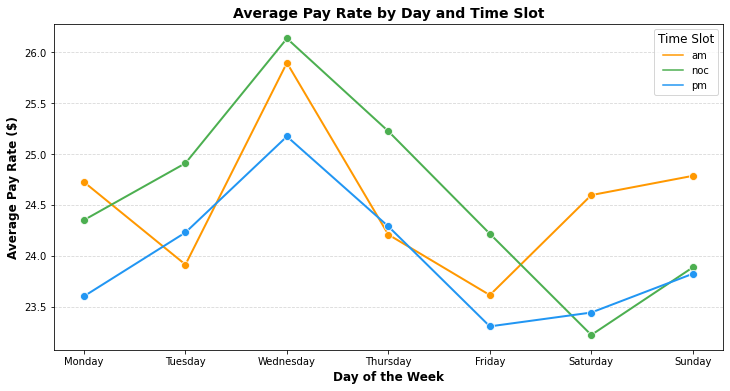

,DAY_OF_WEEK,SLOT,AVG_PAY_RATE
0,Friday,am,23.612993
1,Friday,noc,24.216127
2,Friday,pm,23.305100
3,Monday,am,24.724353
4,Monday,noc,24.351130
5,Monday,pm,23.601764
6,Saturday,am,24.596278
7,Saturday,noc,23.220559
8,Saturday,pm,23.441199
9,Sunday,am,24.785661


In [40]:

# Ensure datetime conversion
data['SHIFT_START_AT'] = pd.to_datetime(data['SHIFT_START_AT'])

# Extract day of the week
data['DAY_OF_WEEK'] = data['SHIFT_START_AT'].dt.day_name()

# Aggregate avg pay rate by day and slot
slotwise_stats = data.groupby(['DAY_OF_WEEK', 'SLOT']).agg(
    AVG_PAY_RATE=('PAY_RATE', 'mean')
).reset_index()

# Ensure days are in order
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
slotwise_stats['DAY_OF_WEEK'] = pd.Categorical(slotwise_stats['DAY_OF_WEEK'], categories=day_order, ordered=True)

# --- Plot 1: Average Pay Rate by Day and Time Slot ---
plt.figure(figsize=(12, 6), facecolor='white')
sns.lineplot(data=slotwise_stats, x='DAY_OF_WEEK', y='AVG_PAY_RATE', hue='SLOT', marker='o',
             palette={'am': '#FF9800', 'pm': '#2196F3', 'noc': '#4CAF50'}, linewidth=2, markersize=8)
plt.title('Average Pay Rate by Day and Time Slot', fontsize=14, fontweight='bold', color='black')
plt.xlabel('Day of the Week', fontsize=12, fontweight='bold', color='black')
plt.ylabel('Average Pay Rate ($)', fontsize=12, fontweight='bold', color='black')
plt.xticks(color='black')
plt.yticks(color='black')
plt.legend(title='Time Slot', title_fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

slotwise_stats

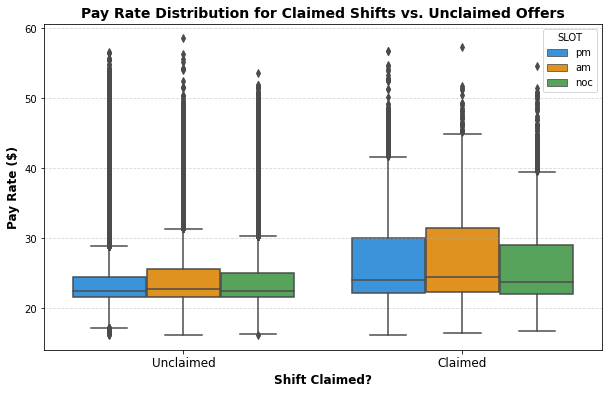

In [49]:
plt.figure(figsize=(10, 6), facecolor='white')
sns.boxplot(data=data, x='CLAIMED', y='PAY_RATE', hue='SLOT', palette={'am': '#FF9800', 'pm': '#2196F3', 'noc': '#4CAF50'})

plt.title('Pay Rate Distribution for Claimed Shifts vs. Unclaimed Offers', fontsize=14, fontweight='bold')
plt.xlabel('Shift Claimed?', fontsize=12, fontweight='bold')
plt.ylabel('Pay Rate ($)', fontsize=12, fontweight='bold')
plt.xticks([0, 1], ['Unclaimed', 'Claimed'], fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()




In [14]:


# Create a binary flag for claimed offers: True if CLAIMED_AT exists, else False
data['CLAIMED'] = data['CLAIMED_AT'].notna()

# First, identify SHIFT_IDs that eventually had a claim
claimed_shift_ids = data.groupby('SHIFT_ID')['CLAIMED'].any()
claimed_shift_ids = claimed_shift_ids[claimed_shift_ids].index

# Filter data to only include shifts that were eventually claimed
data_claimed = data[data['SHIFT_ID'].isin(claimed_shift_ids)]

# Define an aggregation function for each unique claimed SHIFT_ID
def aggregate_claimed_shift(group):
    num_offers = group.shape[0]
    # Calculate average PAY_RATE for unclaimed offers within this shift
    unclaimed_offers = group[group['CLAIMED'] == False]['PAY_RATE']
    avg_unclaimed = unclaimed_offers.mean() if not unclaimed_offers.empty else None
    
    # Calculate the claimed pay rate (if there are multiple, we take their average)
    claimed_offers = group[group['CLAIMED'] == True]['PAY_RATE']
    claimed_pay_rate = claimed_offers.mean() if not claimed_offers.empty else None
    
    return pd.Series({
        'NUM_OFFERS': num_offers,
        'AVG_UNCLAIMED_PAY_RATE': avg_unclaimed,
        'CLAIMED_PAY_RATE': claimed_pay_rate
    })

# Group by SHIFT_ID and apply the aggregation function
aggregated_shifts = data_claimed.groupby('SHIFT_ID').apply(aggregate_claimed_shift).reset_index()

# Sort by number of offers in descending order
aggregated_shifts = aggregated_shifts.sort_values('NUM_OFFERS', ascending=False)

# Print the resulting DataFrame
aggregated_shifts.head(25)




,SHIFT_ID,NUM_OFFERS,AVG_UNCLAIMED_PAY_RATE,CLAIMED_PAY_RATE
8786,6754b23e36deda6cc29e55f1,219.0,29.432569,38.70
4260,6716d77eeaf203a9be830901,218.0,22.593641,22.12
3353,670bd67a642c9c40efa05c65,204.0,22.982266,23.59
10957,6770c8845b9214031e3dfe69,194.0,22.053679,21.63
5096,671fd42a2b12f49dca9b946e,185.0,23.482065,24.90
10934,67707f66c29e7fdd5b7044b0,167.0,23.003434,23.25
5352,67228ffbbe91ce3dde8aae5d,166.0,26.573091,36.59
10159,6765c5ea11595b07d8341609,159.0,32.008408,34.88
9638,675eaa15292873557b312458,158.0,29.794522,31.27
3875,6711fbedb1cdf4ee692f39b8,157.0,31.918526,32.99


In [15]:

# Percentage Difference = ((CLAIMED_PAY_RATE - AVG_UNCLAIMED_PAY_RATE) / AVG_UNCLAIMED_PAY_RATE) * 100
aggregated_shifts = aggregated_shifts.copy()  # assuming aggregated_shifts is your DataFrame from previous aggregation
aggregated_shifts['PERCENT_DIFF'] = (
    (aggregated_shifts['CLAIMED_PAY_RATE'] - aggregated_shifts['AVG_UNCLAIMED_PAY_RATE'])
    / aggregated_shifts['AVG_UNCLAIMED_PAY_RATE'] * 100
)

# Now compute the overall average percentage difference (only consider shifts where unclaimed pay rate is not NaN)
overall_avg_percent_diff = aggregated_shifts['PERCENT_DIFF'].mean()

print("Overall Average Percentage Difference between Claimed and Unclaimed Pay Rates: {:.2f}%".format(overall_avg_percent_diff))


Overall Average Percentage Difference between Claimed and Unclaimed Pay Rates: 2.99%


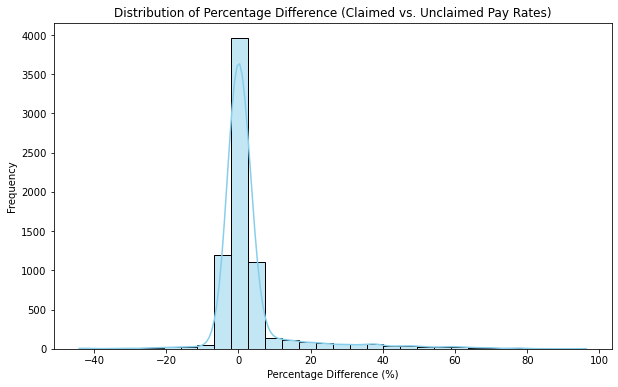

In [17]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))
sns.histplot(aggregated_shifts['PERCENT_DIFF'].dropna(), kde=True, bins=30, color='skyblue')
plt.title("Distribution of Percentage Difference (Claimed vs. Unclaimed Pay Rates)")
plt.xlabel("Percentage Difference (%)")
plt.ylabel("Frequency")
plt.show()


In [50]:
# Check unique values and distribution of the 'IS_NCNS' column
print("Unique Values in 'IS_NCNS' Column:")
print(data['IS_NCNS'].value_counts())

# Check the distribution of 'IS_NCNS' by day of the week
ncns_by_day = data.groupby('DAY_OF_WEEK')['IS_NCNS'].sum().reset_index()
ncns_by_day.columns = ['DAY_OF_WEEK', 'NUM_NCNS']
print("\nNo-Show (NCNS) Counts by Day of the Week:")
print(ncns_by_day)

# Check the distribution of 'IS_NCNS' by shift slot (AM, PM, NOC)
ncns_by_slot = data.groupby('SLOT')['IS_NCNS'].sum().reset_index()
ncns_by_slot.columns = ['SLOT', 'NUM_NCNS']
print("\nNo-Show (NCNS) Counts by Slot:")
print(ncns_by_slot)

# Explore the relationship between 'IS_NCNS' and whether the shift was eventually claimed
ncns_claimed = data.groupby('CLAIMED_AT')['IS_NCNS'].sum().reset_index()
ncns_claimed.columns = ['CLAIMED_AT', 'NUM_NCNS']
print("\nNo-Show (NCNS) Counts by Shift Claim Status (CLAIMED_AT):")
print(ncns_claimed)

# Check if there is any pattern between 'IS_NCNS' and unclaimed shifts
unclaimed_ncns = data[data['CLAIMED_AT'].isna()]
unclaimed_ncns_counts = unclaimed_ncns.groupby('IS_NCNS')['SHIFT_ID'].nunique().reset_index()
unclaimed_ncns_counts.columns = ['IS_NCNS', 'NUM_UNCLAIMED_SHIFTS']
print("\nNo-Show (NCNS) Counts in Unclaimed Shifts:")
print(unclaimed_ncns_counts)

# If you want to dive deeper, you can also check if there is any correlation between NCNS and other numeric columns
# such as 'COMPANY_REV', 'CHARGE_RATE', etc.
correlation_with_ncns = data[['IS_NCNS', 'COMPANY_REV', 'CHARGE_RATE', 'PAY_RATE']].corr()
print("\nCorrelation between 'IS_NCNS' and other numeric columns:")
print(correlation_with_ncns)

ncns_by_slot.head()


Unique Values in 'IS_NCNS' Column:
False    266309
True         31
Name: IS_NCNS, dtype: int64

No-Show (NCNS) Counts by Day of the Week:
  DAY_OF_WEEK  NUM_NCNS
0      Friday         5
1      Monday         4
2    Saturday         3
3      Sunday         4
4    Thursday         4
5     Tuesday         5
6   Wednesday         6

No-Show (NCNS) Counts by Slot:
  SLOT  NUM_NCNS
0   am        17
1  noc         6
2   pm         8

No-Show (NCNS) Counts by Shift Claim Status (CLAIMED_AT):
                   CLAIMED_AT  NUM_NCNS
0     2024-07-29 21:41:00.757         0
1     2024-07-30 17:45:54.999         0
2     2024-08-14 08:00:51.858         0
3     2024-08-19 21:41:06.721         0
4     2024-08-19 21:41:09.419         0
...                       ...       ...
13059 2025-01-20 20:05:19.208         0
13060 2025-01-20 21:31:50.533         0
13061 2025-01-20 21:41:01.587         0
13062 2025-01-20 21:54:17.433         0
13063 2025-01-21 23:46:07.707         0

[13064 rows x 2 columns]

No-S

,SLOT,NUM_NCNS
0,am,17
1,noc,6
2,pm,8


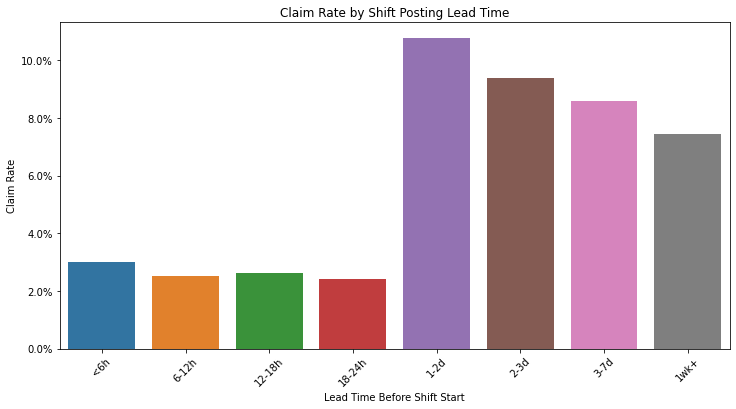

  lead_time_group  total_offers  claim_rate
0             <6h         58905    0.030048
1           6-12h         33461    0.025164
2          12-18h         23083    0.026253
3          18-24h         22025    0.024336
4            1-2d         12903    0.107804
5            2-3d         11402    0.093843
6            3-7d         34324    0.085800
7            1wk+         25887    0.074516


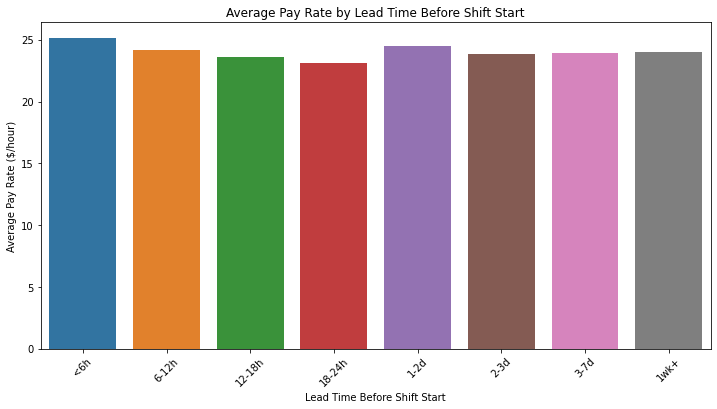

  lead_time_group  avg_pay_rate
0             <6h     25.140264
1           6-12h     24.137883
2          12-18h     23.606935
3          18-24h     23.137597
4            1-2d     24.530225
5            2-3d     23.851986
6            3-7d     23.940510
7            1wk+     23.977496


In [39]:

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# Calculate time to start
data['time_to_start'] = (data['SHIFT_START_AT'] - data['SHIFT_CREATED_AT']).dt.total_seconds() / 3600

# Define lead time bins and labels
bins = [0, 6, 12, 18, 24, 48, 72, 168, 336]  # Hours before shift start
labels = ['<6h', '6-12h', '12-18h', '18-24h', '1-2d', '2-3d', '3-7d', '1wk+']
data['lead_time_group'] = pd.cut(data['time_to_start'], bins=bins, labels=labels)

# 1. Claim Rate by Lead Time Analysis
lead_time_success = data.groupby('lead_time_group', observed=True).agg(
    total_offers=('SHIFT_ID', 'count'),
    claim_rate=('CLAIMED_AT', lambda x: x.notnull().mean())
).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='lead_time_group', y='claim_rate', data=lead_time_success, order=labels)
plt.title("Claim Rate by Shift Posting Lead Time")
plt.xlabel("Lead Time Before Shift Start")
plt.ylabel("Claim Rate")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.xticks(rotation=45)
plt.show()

print(lead_time_success)

# 2. Average Pay Rate by Lead Time Analysis
lead_time_pay = data.groupby('lead_time_group', observed=True).agg(
    avg_pay_rate=('PAY_RATE', 'mean')
).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='lead_time_group', y='avg_pay_rate', data=lead_time_pay, order=labels)
plt.title("Average Pay Rate by Lead Time Before Shift Start")
plt.xlabel("Lead Time Before Shift Start")
plt.ylabel("Average Pay Rate ($/hour)")
plt.xticks(rotation=45)
plt.show()


print(lead_time_pay)



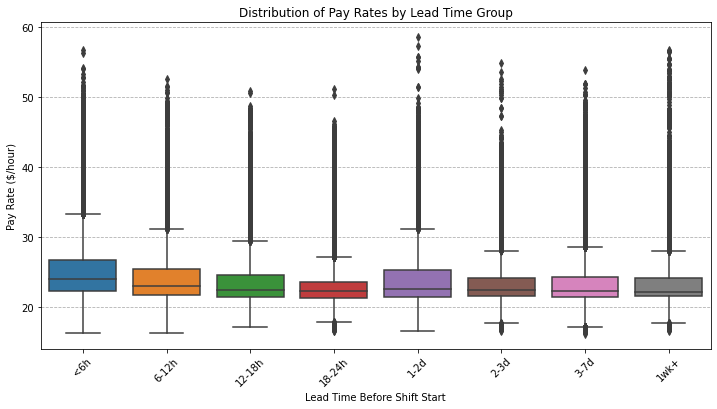

In [20]:
# Distribution of Pay Rates by Lead Time Group
plt.figure(figsize=(12, 6))
sns.boxplot(x='lead_time_group', y='PAY_RATE', data=data, order=labels)
plt.title("Distribution of Pay Rates by Lead Time Group")
plt.xlabel("Lead Time Before Shift Start")
plt.ylabel("Pay Rate ($/hour)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.show()



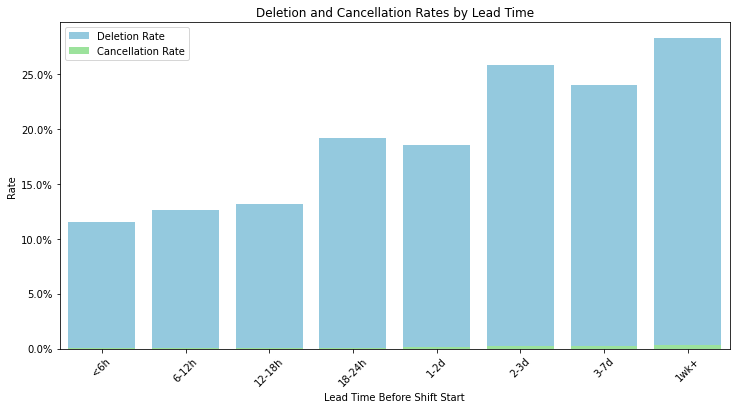

  lead_time_group  deletion_rate  cancellation_rate  total_offers
0             <6h       0.115101           0.000153         58905
1           6-12h       0.126237           0.000359         33461
2          12-18h       0.132219           0.000433         23083
3          18-24h       0.191918           0.000318         22025
4            1-2d       0.185383           0.001860         12903
5            2-3d       0.258551           0.002631         11402
6            3-7d       0.240298           0.002680         34324
7            1wk+       0.283038           0.003013         25887


In [35]:


# Calculate time to start
data['time_to_start'] = (data['SHIFT_START_AT'] - data['SHIFT_CREATED_AT']).dt.total_seconds() / 3600

# Define lead time bins and labels
bins = [0, 6, 12, 18, 24, 48, 72, 168, 336]  # Hours before shift start
labels = ['<6h', '6-12h', '12-18h', '18-24h', '1-2d', '2-3d', '3-7d', '1wk+']
data['lead_time_group'] = pd.cut(data['time_to_start'], bins=bins, labels=labels)

# Calculate deletion and cancellation rates
data['is_deleted'] = data['DELETED_AT'].notnull()
data['is_canceled'] = data['CANCELED_AT'].notnull()

# Analyze deletion and cancellation rates by lead time
deletion_cancellation = data.groupby('lead_time_group').agg({
    'is_deleted': 'mean',
    'is_canceled': 'mean',
    'SHIFT_ID': 'count'
}).reset_index()

deletion_cancellation = deletion_cancellation.rename(columns={
    'is_deleted': 'deletion_rate',
    'is_canceled': 'cancellation_rate',
    'SHIFT_ID': 'total_offers'
})

# Plot deletion and cancellation rates
plt.figure(figsize=(12, 6))
sns.barplot(x='lead_time_group', y='deletion_rate', data=deletion_cancellation, color='skyblue', label='Deletion Rate')
sns.barplot(x='lead_time_group', y='cancellation_rate', data=deletion_cancellation, color='lightgreen', label='Cancellation Rate')
plt.title("Deletion and Cancellation Rates by Lead Time")
plt.xlabel("Lead Time Before Shift Start")
plt.ylabel("Rate")
plt.legend()
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.show()

# Print summary statistics
print(deletion_cancellation)



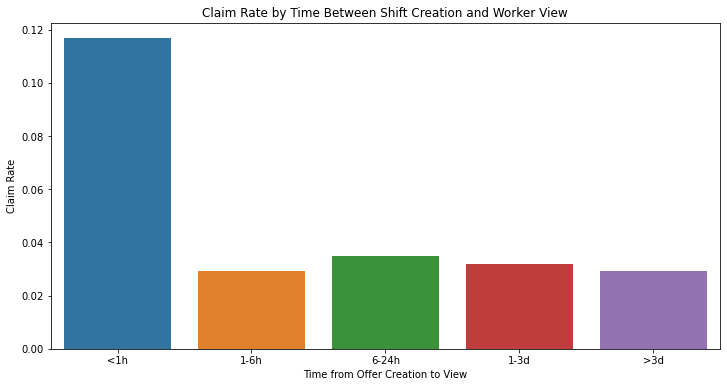

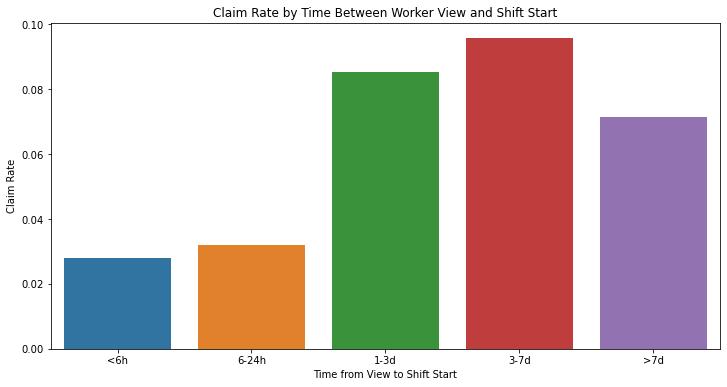

  offer_to_view_bin  total_offers  claim_rate
0               <1h         56374    0.116809
1              1-6h         74585    0.029108
2             6-24h         49432    0.034714
3              1-3d         25350    0.032032
4               >3d         60599    0.029373
  view_to_start_bin  total_offers  claim_rate
0               <6h         96454    0.028086
1             6-24h         72951    0.032008
2              1-3d         30042    0.085347
3              3-7d         27577    0.095768
4               >7d         39316    0.071599


In [25]:


# Calculate time differences
data['offer_to_view_time'] = (data['OFFER_VIEWED_AT'] - data['SHIFT_CREATED_AT']).dt.total_seconds() / 3600
data['view_to_start_time'] = (data['SHIFT_START_AT'] - data['OFFER_VIEWED_AT']).dt.total_seconds() / 3600

# Create bins for time differences
data['offer_to_view_bin'] = pd.cut(data['offer_to_view_time'], bins=[-float('inf'), 1, 6, 24, 72, float('inf')], labels=['<1h', '1-6h', '6-24h', '1-3d', '>3d'])
data['view_to_start_bin'] = pd.cut(data['view_to_start_time'], bins=[-float('inf'), 6, 24, 72, 168, float('inf')], labels=['<6h', '6-24h', '1-3d', '3-7d', '>7d'])

# Analyze claim rate based on offer-to-view time
offer_to_view_analysis = data.groupby('offer_to_view_bin').agg(
    total_offers=('SHIFT_ID', 'count'),
    claim_rate=('CLAIMED_AT', lambda x: x.notnull().mean())
).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='offer_to_view_bin', y='claim_rate', data=offer_to_view_analysis)
plt.title("Claim Rate by Time Between Shift Creation and Worker View")
plt.xlabel("Time from Offer Creation to View")
plt.ylabel("Claim Rate")
plt.show()

# Analyze claim rate based on view-to-start time
view_to_start_analysis = data.groupby('view_to_start_bin').agg(
    total_offers=('SHIFT_ID', 'count'),
    claim_rate=('CLAIMED_AT', lambda x: x.notnull().mean())
).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='view_to_start_bin', y='claim_rate', data=view_to_start_analysis)
plt.title("Claim Rate by Time Between Worker View and Shift Start")
plt.xlabel("Time from View to Shift Start")
plt.ylabel("Claim Rate")
plt.show()

print(offer_to_view_analysis)
print(view_to_start_analysis)

